# Лабораторная работа №2
## Задачи регрессии и классификации. Линейные модели: линейная и логистическая регрессии 

Импортируем библиотеку:

In [1]:
import pandas as pd

Загружаем и смотрим на датасет:

In [2]:
df = pd.read_csv("../lab_1/data/StudentsPerformance_processed.csv", index_col=0)
df.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,0.181890,0.395652,False,True,False,False,False,True,False,False,False,False,True,True
1,69,1.534130,1.370677,False,False,True,False,False,False,False,False,True,False,True,False
2,90,1.909752,1.718901,False,True,False,False,False,False,False,True,False,False,True,True
3,47,-0.944977,-1.693689,True,False,False,False,False,False,False,False,False,False,False,True
4,76,0.632636,0.465296,True,False,True,False,False,False,False,False,True,False,True,True


## Регрессия

Разделяем данные на матрицу признаков и вектор целевой переменной:

In [3]:
X = df.drop("math score", axis=1)
y = df["math score"]

print(X.shape)
print(y.shape)

(1000, 14)
(1000,)


Разделаем данные на обущающую и тестовую выборки в отношении 80 на 20:

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Импортируем модель линейной регрессии и обучаем её на обучающей выборке:

In [5]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Получим предсказанные моделью значения:

In [6]:
y_pred_test = linear_model.predict(X_test)

Считаем необходимые метрики регрессии:

In [7]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

print("RMSE:", root_mean_squared_error(y_test, y_pred_test))
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("R2:", r2_score(y_test, y_pred_test))

RMSE: 12.02147313320563
MAE: 8.477313959932587
R2: 0.4061117509920966


Построим график фактических и предсказанных моделью значений:

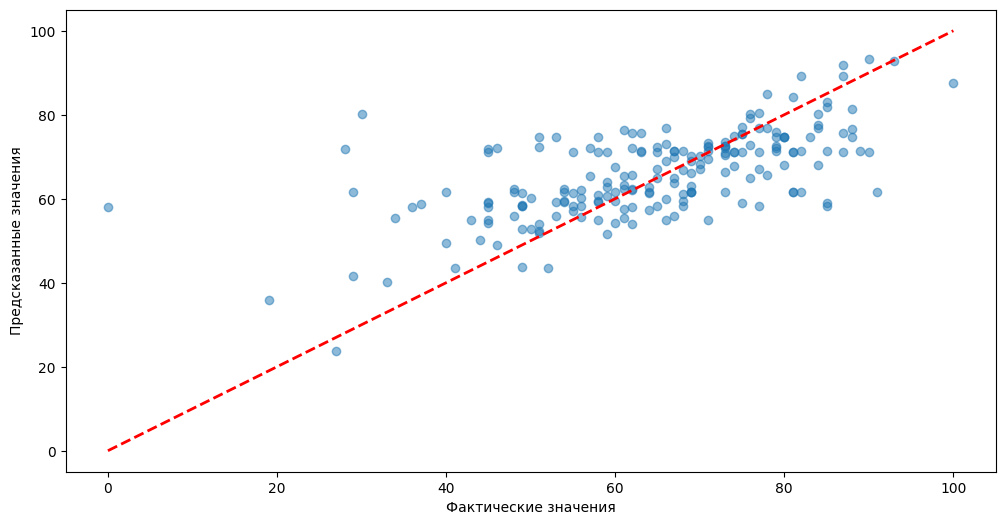

In [46]:
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.show()

Попытаемся улучшить метрики модели, используя L2 регуляризацию:

In [8]:
from sklearn.linear_model import Ridge
l2_linear_model = Ridge(alpha=1)

l2_linear_model.fit(X_train, y_train)
l2_y_pred_test = l2_linear_model.predict(X_test)

print("RMSE (Ridge):", root_mean_squared_error(y_test, y_pred_test))
print("MAE (Ridge):", mean_absolute_error(y_test, y_pred_test))
print("R2 (Ridge):", r2_score(y_test, y_pred_test))

RMSE (Ridge): 12.02147313320563
MAE (Ridge): 8.477313959932587
R2 (Ridge): 0.4061117509920966


## Классификация

Загружаем набор данных для кассификации:

In [9]:
df_clf = pd.read_csv("data/StudentsPerformance_clf.csv")
df_clf.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none,is_passed
0,0.390024,0.181890,0.395652,False,True,False,False,False,True,False,False,False,False,True,True,True
1,0.192076,1.534130,1.370677,False,False,True,False,False,False,False,False,True,False,True,False,True
2,1.577711,1.909752,1.718901,False,True,False,False,False,False,False,True,False,False,True,True,True
3,-1.259543,-0.944977,-1.693689,True,False,False,False,False,False,False,False,False,False,False,True,False
4,0.653954,0.632636,0.465296,True,False,True,False,False,False,False,False,True,False,True,True,True


Оцениваем баланс классов целевой переменной:

In [10]:
df_clf.is_passed.value_counts()

is_passed
False    618
True     382
Name: count, dtype: int64

Разделяем данные:

In [11]:
X_clf = df_clf.drop("is_passed", axis=1)
y_clf = df_clf.is_passed

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

Обучаем модель логистической регрессии с параметром, который учитывает дисбаланс классов:

In [35]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(class_weight="balanced")
logreg_model.fit(X_clf_train, y_clf_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Делаем предсказание:

In [36]:
y_clf_pred_test = logreg_model.predict(X_clf_test)

Посчитаем точность модели:

In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_clf_test, y_clf_pred_test)
print(accuracy)

0.745


Построим матрицу ошибок классификации:

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_clf_test, y_clf_pred_test)

Text(0.5, 3.722222222222216, 'Predicted label')

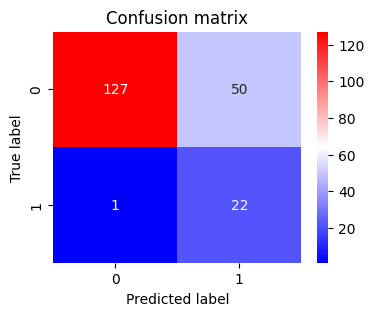

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='bwr')
plt.title('Confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')

Выведем общий отчёт по метрикам классификации:

In [40]:
from sklearn.metrics import classification_report

report = classification_report(y_clf_test, y_clf_pred_test)
print(report)

              precision    recall  f1-score   support

       False       0.99      0.72      0.83       177
        True       0.31      0.96      0.46        23

    accuracy                           0.74       200
   macro avg       0.65      0.84      0.65       200
weighted avg       0.91      0.74      0.79       200



Отдельно посчитаем наиболее важные метрики - recall, precision и f1-меру:

In [41]:
from sklearn.metrics import recall_score, precision_score, f1_score

recall = recall_score(y_clf_test, y_clf_pred_test)
print("Recall:", recall)
precision = precision_score(y_clf_test, y_clf_pred_test)
print("Precision:", recall)
f1 = f1_score(y_clf_test, y_clf_pred_test)
print("F1:", f1)

Recall: 0.9565217391304348
Precision: 0.9565217391304348
F1: 0.4631578947368421
